In [1]:
import os
import sys
path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(splitted[0]+os.sep, splitted[1], splitted[2], splitted[3])
src_path = os.path.join(user_independent, 'GitHub', 'Photoswitching')
sys.path.append(src_path)

import src.antibunching as ab
import src.blinking as bl
import src.cy5_properties as cy5
import src.distributions as dist
import src.emissions as em
import src.fcs as fc
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.statistics as st
import src.tcspc as tc
import src.transitions as tr

import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2

import warnings
def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache
        line = linecache.getline(filename, lineno)
    return f'WARNING for line: {line} {msg} \n' 
warnings.formatwarning = custom_warning_format

c:\Users\ebert\miniconda3\envs\markovmodels\lib\site-packages\pycorrelate\pycorrelate.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def ucorrelate(t, u, maxlag=None):


# Cy5 fluorescence trajectories

In [ ]:
from matplotlib import rcParams
rcParams['axes.facecolor'] = "#081017"
rcParams['axes.edgecolor'] = 'FFFFFF'
rcParams['axes.labelcolor'] = 'FFFFFF'
rcParams['axes.titlecolor'] = 'FFFFFF'

## 1 fluorophore

In [4]:
fluorophores = fl.construct_fluorophores(name='cy5', distance=1, count=1,
                                        parameter_set='test')
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(irradiance=2.5, wavelength=640,
                                                  bleaching=False, energy_transfer=False,
                                                  dstorm=True, reducing_agent='mea',
                                                  concentration=140, ph=8)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
transition_set.transition_df


,transition_type,abbreviation,initial_state,final_state,rate,photon,energy_transfer,distance,absorbing
id,,,,,,,,,
0,TransitionType.EXCITATION,EXC,SingleState.S0,SingleState.S1,7.269626e+06,False,False,None,False
1,TransitionType.FLUORESCENT_EMISSION,FLU,SingleState.S1,SingleState.S0,2.700000e+08,True,False,None,False
2,TransitionType.INTERSYSTEM_CROSSING_ST,ISCST,SingleState.S1,SingleState.T1,8.300000e+05,False,False,None,False
3,TransitionType.INTERSYSTEM_CROSSING_TS,ISCTS,SingleState.T1,SingleState.S0,5.000000e+03,False,False,None,False
4,TransitionType.ISOMERIZATION,ISO,SingleState.S1,SingleState.Cis,2.000000e+07,False,False,None,False
5,TransitionType.BACKISOMERIZATION,BISO,SingleState.Cis,SingleState.S0,1.369280e+05,False,False,None,False
6,TransitionType.INTERNAL_CONVERSION_S,ICS,SingleState.S1,SingleState.S0,7.091700e+08,False,False,None,False
7,TransitionType.ET_CYCLE_T,ETT,SingleState.T1,SingleState.S0,4.291480e+05,False,False,None,False
8,TransitionType.ET_CYCLE_S,ETS,SingleState.S1,SingleState.S0,4.291480e+06,False,False,None,False


In [13]:
simulation = si.Simulation(transition_set)
simulation.run(size=1e7, end_time=300, seed=3)
emissions = em.Emissions(simulation, photon_collection_rate=0.01, resample='1ms',
                         emccd_gain=100, seed=3)
blinking = bl.Blinking(emissions)
times_1, values_1 = bl.get_off_statistics(simulation, index=0, 
                                          event_indices=emissions.event_indices)

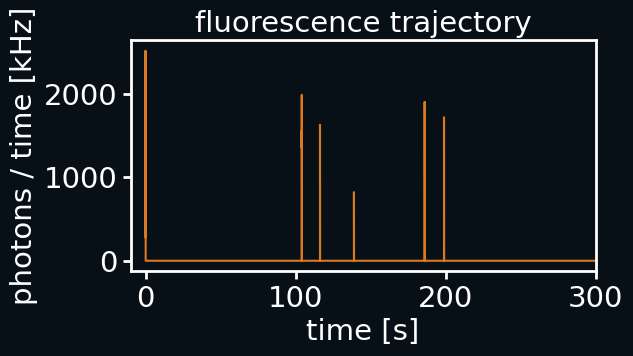

In [41]:
ax = emissions.plot(mode='time_series', color="#DB7921", 
               ylabel='photons / time [kHz]', xlim=[-10, 300],
               tick_params={'colors': "#FFFFFF"})
fig = mi.get_figure(ax)
fig.patch.set_facecolor("#081017")
fig.savefig(user_independent + '\\1_fluorophore.svg', bbox_inches = "tight")

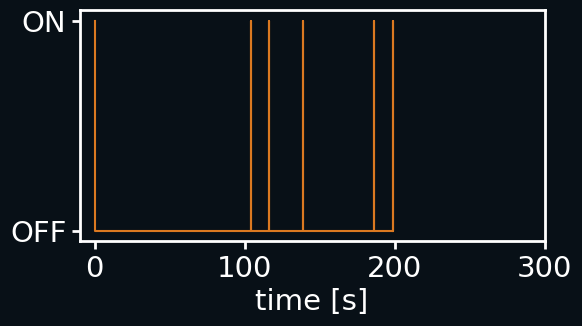

In [46]:
ax = fi.universal_figure(type_='line', data=[times_1, values_1], xlabel='time [s]',
                    ylabel='', yticks=[0, 1], tick_params={'colors': "#FFFFFF"},
                    yticklabels={'labels': ['OFF', 'ON']}, color="#DB7921", 
                    xlim=[-10, 300])
fig = mi.get_figure(ax)
fig.patch.set_facecolor("#081017")
fig.savefig(user_independent + '\\1_fluorophore_bl.svg', bbox_inches = "tight")

## 3 fluorophores

In [48]:
fluorophores = fl.construct_fluorophores(name='cy5', distance=1, count=3,
                                        parameter_set='test')
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(irradiance=2.5, wavelength=640,
                                                  bleaching=False, energy_transfer=False,
                                                  dstorm=True, reducing_agent='mea',
                                                  concentration=140, ph=8)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
transition_set.transition_df


,transition_type,abbreviation,initial_state,final_state,rate,photon,energy_transfer,distance,absorbing
id,,,,,,,,,
0,TransitionType.EXCITATION,EXC,SingleState.S0,SingleState.S1,7.269626e+06,False,False,None,False
1,TransitionType.FLUORESCENT_EMISSION,FLU,SingleState.S1,SingleState.S0,2.700000e+08,True,False,None,False
2,TransitionType.INTERSYSTEM_CROSSING_ST,ISCST,SingleState.S1,SingleState.T1,8.300000e+05,False,False,None,False
3,TransitionType.INTERSYSTEM_CROSSING_TS,ISCTS,SingleState.T1,SingleState.S0,5.000000e+03,False,False,None,False
4,TransitionType.ISOMERIZATION,ISO,SingleState.S1,SingleState.Cis,2.000000e+07,False,False,None,False
5,TransitionType.BACKISOMERIZATION,BISO,SingleState.Cis,SingleState.S0,1.369280e+05,False,False,None,False
6,TransitionType.INTERNAL_CONVERSION_S,ICS,SingleState.S1,SingleState.S0,7.091700e+08,False,False,None,False
7,TransitionType.ET_CYCLE_T,ETT,SingleState.T1,SingleState.S0,4.291480e+05,False,False,None,False
8,TransitionType.ET_CYCLE_S,ETS,SingleState.S1,SingleState.S0,4.291480e+06,False,False,None,False


In [49]:
simulation = si.Simulation(transition_set)
simulation.run(size=1e7, end_time=300, seed=3)
emissions = em.Emissions(simulation, photon_collection_rate=0.01, resample='1ms',
                         emccd_gain=100, seed=3)
blinking = bl.Blinking(emissions)
times_1, values_1 = bl.get_off_statistics(simulation, index=0, 
                                          event_indices=emissions.event_indices)
times_2, values_2 = bl.get_off_statistics(simulation, index=1, 
                                          event_indices=emissions.event_indices)
times_3, values_3 = bl.get_off_statistics(simulation, index=2, 
                                          event_indices=emissions.event_indices)

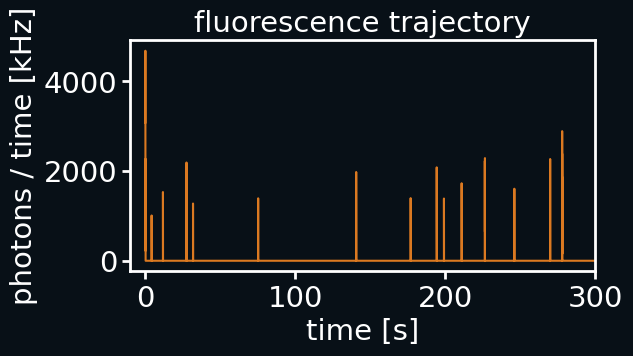

In [50]:
ax = emissions.plot(mode='time_series', color="#DB7921", 
               ylabel='photons / time [kHz]', xlim=[-10, 300],
               tick_params={'colors': "#FFFFFF"})
fig = mi.get_figure(ax)
fig.patch.set_facecolor("#081017")
fig.savefig(user_independent + '\\3_fluorophores.svg', bbox_inches = "tight")

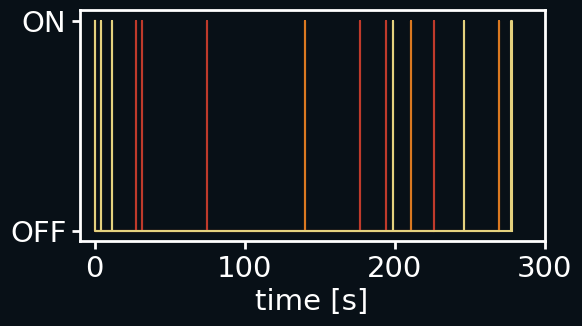

In [53]:
ax = fi.universal_figure(type_='line', data=[times_2, values_2], color="#DB7921", 
                    xlim=[-10, 300])
fi.universal_figure(type_='line', data=[times_3, values_3], color='#BF3A2B', 
                    xlim=[-10, 300], axes=ax[0, 0])
fi.universal_figure(type_='line', data=[times_1, values_1], xlabel='time [s]',
                    ylabel='', yticks=[0, 1], tick_params={'colors': "#FFFFFF"},
                    yticklabels={'labels': ['OFF', 'ON']}, color='#E4D17E', 
                    xlim=[-10, 300], axes=ax[0, 0])
fig = mi.get_figure(ax)
fig.patch.set_facecolor("#081017")
fig.savefig(user_independent + '\\3_fluorophores_bl.svg', bbox_inches = "tight")

## 3 fluorophores TE rate

In [54]:
fluorophores = fl.construct_fluorophores(name='cy5', distance=1, count=3,
                                        parameter_set='test')
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(irradiance=2.5, wavelength=640,
                                                  bleaching=False, energy_transfer=False,
                                                  dstorm=True, reducing_agent='mea',
                                                  concentration=140, ph=8)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.adjust_rates(change_dict={'OXI': 2e-1})
transition_set.finalize()
transition_set.transition_df


,transition_type,abbreviation,initial_state,final_state,rate,photon,energy_transfer,distance,absorbing
id,,,,,,,,,
0,TransitionType.EXCITATION,EXC,SingleState.S0,SingleState.S1,7.269626e+06,False,False,None,False
1,TransitionType.FLUORESCENT_EMISSION,FLU,SingleState.S1,SingleState.S0,2.700000e+08,True,False,None,False
2,TransitionType.INTERSYSTEM_CROSSING_ST,ISCST,SingleState.S1,SingleState.T1,8.300000e+05,False,False,None,False
3,TransitionType.INTERSYSTEM_CROSSING_TS,ISCTS,SingleState.T1,SingleState.S0,5.000000e+03,False,False,None,False
4,TransitionType.ISOMERIZATION,ISO,SingleState.S1,SingleState.Cis,2.000000e+07,False,False,None,False
5,TransitionType.BACKISOMERIZATION,BISO,SingleState.Cis,SingleState.S0,1.369280e+05,False,False,None,False
6,TransitionType.INTERNAL_CONVERSION_S,ICS,SingleState.S1,SingleState.S0,7.091700e+08,False,False,None,False
7,TransitionType.ET_CYCLE_T,ETT,SingleState.T1,SingleState.S0,4.291480e+05,False,False,None,False
8,TransitionType.ET_CYCLE_S,ETS,SingleState.S1,SingleState.S0,4.291480e+06,False,False,None,False


In [55]:
simulation = si.Simulation(transition_set)
simulation.run(size=1e7, end_time=300, seed=3)
emissions = em.Emissions(simulation, photon_collection_rate=0.01, resample='1ms',
                         emccd_gain=100, seed=3)
blinking = bl.Blinking(emissions)
times_1, values_1 = bl.get_off_statistics(simulation, index=0, 
                                          event_indices=emissions.event_indices)
times_2, values_2 = bl.get_off_statistics(simulation, index=1, 
                                          event_indices=emissions.event_indices)
times_3, values_3 = bl.get_off_statistics(simulation, index=2, 
                                          event_indices=emissions.event_indices)

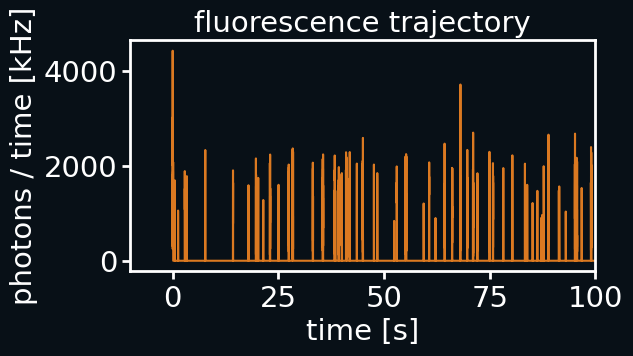

In [58]:
ax = emissions.plot(mode='time_series', color="#DB7921", 
               ylabel='photons / time [kHz]', xlim=[-10, 100],
               tick_params={'colors': "#FFFFFF"})
fig = mi.get_figure(ax)
fig.patch.set_facecolor("#081017")
fig.savefig(user_independent + '\\TE_rate.svg', bbox_inches = "tight")

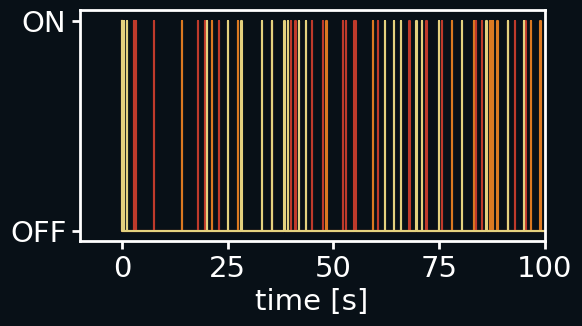

In [59]:
ax = fi.universal_figure(type_='line', data=[times_2, values_2], color="#DB7921", 
                    xlim=[-10, 100])
fi.universal_figure(type_='line', data=[times_3, values_3], color='#BF3A2B', 
                    xlim=[-10, 100], axes=ax[0, 0])
fi.universal_figure(type_='line', data=[times_1, values_1], xlabel='time [s]',
                    ylabel='', yticks=[0, 1], tick_params={'colors': "#FFFFFF"},
                    yticklabels={'labels': ['OFF', 'ON']}, color='#E4D17E', 
                    xlim=[-10, 100], axes=ax[0, 0])
fig = mi.get_figure(ax)
fig.patch.set_facecolor("#081017")
fig.savefig(user_independent + '\\TE_rate_bl.svg', bbox_inches = "tight")

## 3 fluorophores OFF ET

In [73]:
fluorophores = fl.construct_fluorophores(name='cy5', distance=1, count=3,
                                        parameter_set='test')
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(irradiance=2.5, wavelength=640,
                                                  bleaching=False, energy_transfer=True,
                                                  dstorm=True, reducing_agent='mea',
                                                  concentration=140, ph=8)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.filter_by_abbreviation(
    remove_list=['HFRET', 'CFRET', 'STA'])
transition_set = transition_set.adjust_rates(change_dict={'OFRET(1.0)': 1e5})
transition_set.finalize()
transition_set.transition_df


,transition_type,abbreviation,initial_state,final_state,rate,photon,energy_transfer,distance,absorbing
id,,,,,,,,,
0,TransitionType.EXCITATION,EXC,SingleState.S0,SingleState.S1,7.269626e+06,False,False,NaN,False
1,TransitionType.FLUORESCENT_EMISSION,FLU,SingleState.S1,SingleState.S0,2.700000e+08,True,False,NaN,False
2,TransitionType.INTERSYSTEM_CROSSING_ST,ISCST,SingleState.S1,SingleState.T1,8.300000e+05,False,False,NaN,False
3,TransitionType.INTERSYSTEM_CROSSING_TS,ISCTS,SingleState.T1,SingleState.S0,5.000000e+03,False,False,NaN,False
4,TransitionType.ISOMERIZATION,ISO,SingleState.S1,SingleState.Cis,2.000000e+07,False,False,NaN,False
5,TransitionType.BACKISOMERIZATION,BISO,SingleState.Cis,SingleState.S0,1.369280e+05,False,False,NaN,False
6,TransitionType.INTERNAL_CONVERSION_S,ICS,SingleState.S1,SingleState.S0,7.091700e+08,False,False,NaN,False
7,TransitionType.ET_CYCLE_T,ETT,SingleState.T1,SingleState.S0,4.291480e+05,False,False,NaN,False
8,TransitionType.ET_CYCLE_S,ETS,SingleState.S1,SingleState.S0,4.291480e+06,False,False,NaN,False


In [74]:
simulation = si.Simulation(transition_set)
simulation.run(size=1e7, end_time=1, seed=3)
emissions = em.Emissions(simulation, photon_collection_rate=0.01, resample='1ms',
                         emccd_gain=100, seed=3)
blinking = bl.Blinking(emissions)
times_1, values_1 = bl.get_off_statistics(simulation, index=0, 
                                          event_indices=emissions.event_indices)
times_2, values_2 = bl.get_off_statistics(simulation, index=1, 
                                          event_indices=emissions.event_indices)
times_3, values_3 = bl.get_off_statistics(simulation, index=2, 
                                          event_indices=emissions.event_indices)

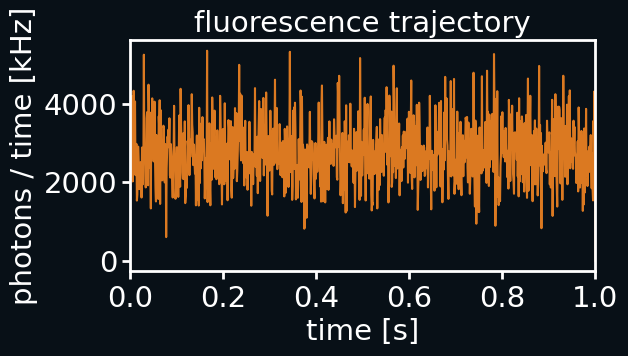

In [76]:
ax = emissions.plot(mode='time_series', color="#DB7921", 
               ylabel='photons / time [kHz]', xlim=[0, 1],
               tick_params={'colors': "#FFFFFF"})
fig = mi.get_figure(ax)
fig.patch.set_facecolor("#081017")
fig.savefig(user_independent + '\\OFF_ET.svg', bbox_inches = "tight")

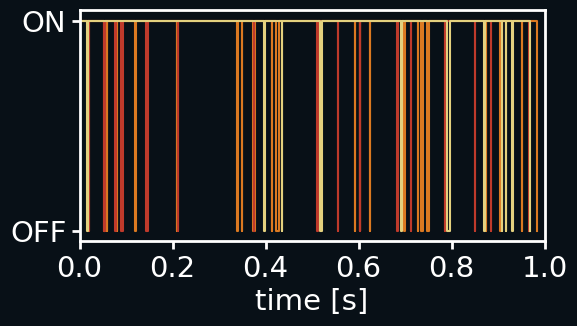

In [78]:
ax = fi.universal_figure(type_='line', data=[times_2, values_2], color="#DB7921", 
                    xlim=[0, 1])
fi.universal_figure(type_='line', data=[times_3, values_3], color='#BF3A2B', 
                    xlim=[0, 1], axes=ax[0, 0])
fi.universal_figure(type_='line', data=[times_1, values_1], xlabel='time [s]',
                    ylabel='', yticks=[0, 1], tick_params={'colors': "#FFFFFF"},
                    yticklabels={'labels': ['OFF', 'ON']}, color='#E4D17E', 
                    xlim=[0, 1], axes=ax[0, 0])
fig = mi.get_figure(ax)
fig.patch.set_facecolor("#081017")
fig.savefig(user_independent + '\\OFF_ET_bl.svg', bbox_inches = "tight")

## 2 fluorophores OFF ET

In [79]:
fluorophores = fl.construct_fluorophores(name='cy5', distance=1, count=2,
                                        parameter_set='test')
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(irradiance=2.5, wavelength=640,
                                                  bleaching=False, energy_transfer=True,
                                                  dstorm=True, reducing_agent='mea',
                                                  concentration=140, ph=8)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.filter_by_abbreviation(
    remove_list=['HFRET', 'CFRET', 'STA'])
transition_set = transition_set.adjust_rates(change_dict={'OFRET(1.0)': 1e4})
transition_set.finalize()
transition_set.transition_df

,transition_type,abbreviation,initial_state,final_state,rate,photon,energy_transfer,distance,absorbing
id,,,,,,,,,
0,TransitionType.EXCITATION,EXC,SingleState.S0,SingleState.S1,7.269626e+06,False,False,NaN,False
1,TransitionType.FLUORESCENT_EMISSION,FLU,SingleState.S1,SingleState.S0,2.700000e+08,True,False,NaN,False
2,TransitionType.INTERSYSTEM_CROSSING_ST,ISCST,SingleState.S1,SingleState.T1,8.300000e+05,False,False,NaN,False
3,TransitionType.INTERSYSTEM_CROSSING_TS,ISCTS,SingleState.T1,SingleState.S0,5.000000e+03,False,False,NaN,False
4,TransitionType.ISOMERIZATION,ISO,SingleState.S1,SingleState.Cis,2.000000e+07,False,False,NaN,False
5,TransitionType.BACKISOMERIZATION,BISO,SingleState.Cis,SingleState.S0,1.369280e+05,False,False,NaN,False
6,TransitionType.INTERNAL_CONVERSION_S,ICS,SingleState.S1,SingleState.S0,7.091700e+08,False,False,NaN,False
7,TransitionType.ET_CYCLE_T,ETT,SingleState.T1,SingleState.S0,4.291480e+05,False,False,NaN,False
8,TransitionType.ET_CYCLE_S,ETS,SingleState.S1,SingleState.S0,4.291480e+06,False,False,NaN,False


In [80]:
simulation = si.Simulation(transition_set)
simulation.run(size=1e7, end_time=100, seed=3)
emissions = em.Emissions(simulation, photon_collection_rate=0.01, resample='1ms',
                         emccd_gain=100, seed=3)
blinking = bl.Blinking(emissions)
times_1, values_1 = bl.get_off_statistics(simulation, index=0, 
                                          event_indices=emissions.event_indices)
times_2, values_2 = bl.get_off_statistics(simulation, index=1, 
                                          event_indices=emissions.event_indices)


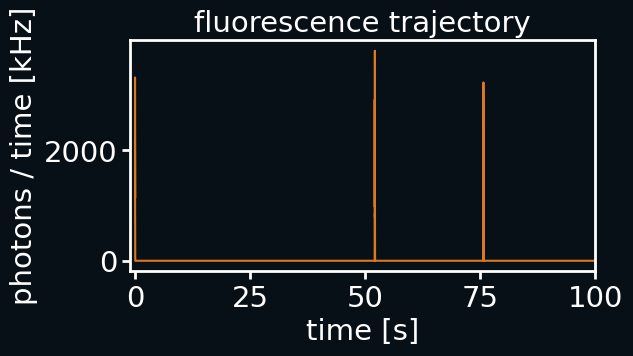

In [81]:
ax = emissions.plot(mode='time_series', color="#DB7921", 
               ylabel='photons / time [kHz]', xlim=[-1, 100],
               tick_params={'colors': "#FFFFFF"})
fig = mi.get_figure(ax)
fig.patch.set_facecolor("#081017")
fig.savefig(user_independent + '\\OFF_ET_2.svg', bbox_inches = "tight")

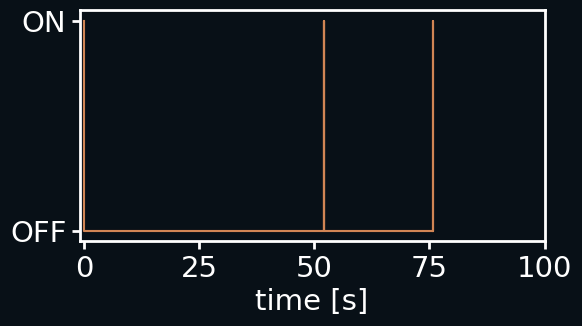

In [85]:
ax = fi.universal_figure(type_='line', data=[times_2, values_2], color='#BF3A2B', 
                    xlim=[-1, 100])
fi.universal_figure(type_='line', data=[times_1, values_1], xlabel='time [s]',
                    ylabel='', yticks=[0, 1], tick_params={'colors': "#FFFFFF"},
                    yticklabels={'labels': ['OFF', 'ON']}, color='#E4D17E', 
                    xlim=[-1, 100], axes=ax[0, 0], alpha=0.5)
fig = mi.get_figure(ax)
fig.patch.set_facecolor("#081017")
fig.savefig(user_independent + '\\OFF_ET_bl_2.svg', bbox_inches = "tight")

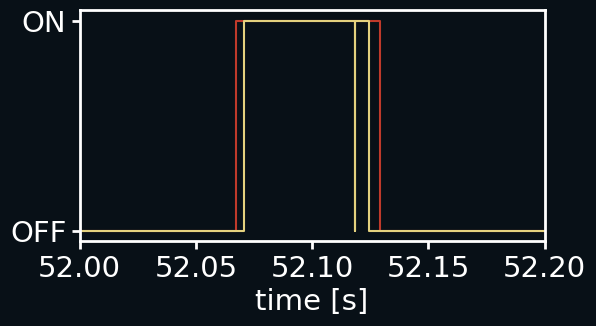

In [89]:
ax = fi.universal_figure(type_='line', data=[times_2, values_2], color='#BF3A2B', 
                    xlim=[52, 52.2])
fi.universal_figure(type_='line', data=[times_1, values_1], xlabel='time [s]',
                    ylabel='', yticks=[0, 1], tick_params={'colors': "#FFFFFF"},
                    yticklabels={'labels': ['OFF', 'ON']}, color='#E4D17E', 
                    xlim=[52, 52.2], axes=ax[0, 0])
fig = mi.get_figure(ax)
fig.patch.set_facecolor("#081017")
fig.savefig(user_independent + '\\OFF_ET_bl_2_2.svg', bbox_inches = "tight")